# CRE Assignment 4 - Group 2

---

## Table of Contents

**2.1 Background**&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; \
&emsp;1.1 Residence Time Distribution \
&emsp;1.2 Backmixing Models for PFR \
&emsp;&emsp;1.2.1 Dispersion Model \
&emsp;&emsp;1.2.2 Danckwerts Boundary Conditions 

**2.2 Mathematical Framework** \
&emsp;2.1 Governing Equations\
&emsp;2.2 Boundary Conditions (Danckwerts)\
&emsp;2.3 CSTR Cascade Model

**3. Implementation**\
&emsp;3.1 Parameters and Setup\
&emsp;3.2 BVP Solver — Dispersion Model\
&emsp;3.3 IVP Solver — PFR Limiting Case\
&emsp;3.4 CSTR Cascade

**4. Results and Discussion**\
&emsp;4.1 Validation — BVP vs. IVP\
&emsp;4.2 Influence of Backmixing (Bo-Number Variation)\
&emsp;&emsp;Theoretical and practical boundary cases\
&emsp;4.3 CSTR Cascade vs. Dispersion Model

**5. Conclusions**

**6. AI Use and Reflection**

---

In [1]:
# ============================================================
# IMPORT SECTION
# ============================================================

import numpy as np                          # numerical arrays and math
import scipy.integrate as integ             # initial value problem solver (solve_ivp)
from scipy.integrate import solve_bvp       # boundary value problem solver
import matplotlib.pyplot as plt             # plotting
from matplotlib.lines import Line2D         # custom legend handles
from matplotlib.patches import Patch        # custom legend handles (filled)

# **1. Introduction**

Tubular reactors are a commonly used reactor type in the chemical industry. They are mainly used for the production of bulk chemicals, utilizing their potential for continous production in processes like the hydrolysis of ethylene oxide to ethylene glycol as seen in assignment 3 of this lecture. In assignemnt 3 we simulated a PFTR, a tubular reactor with the assumption of a perfect plug flow profile, which simplifies the mass transport and consequently the mass balance equation for the model.

In this assignment we will expand the model of a tubular reactor away from the assumption of perfect plug flow to a more realistic approximation of real world behaviour. For this we will introduce the dispersion model, which accounts for backmixing of the reaction mixture inside of the reactor due to differences in residence time for different fluid elements that occur in real reactors. We will then compare the results of this model for describing real reactor behaviour with the cascade model to discuss the up- and downsides of both. 

The work of this assignment will expand our ability to describe real world systems with mathematical models. The behaviour of real systems almost always differs from ideal assumptions. A well reasoned method of accounting for these deviations is an important tool for chemical engineers, and understanding these tools and their usage cases is vital for students of chemical engineering.

# **2. Background and mathematical Framework**

# **3. Implementation**

In [2]:
# ============================================================
# GLOBAL PARAMETERS
# ============================================================

# --- Reactor geometry ---
L    = 10.0             # reactor length, m
d_R  = 0.032            # reactor tube inner diameter, m
d_in = 0.150            # upstream pipe diameter (feed section), m

A_R  = np.pi / 4 * d_R**2   # reactor cross-sectional area, m^2
A_in = np.pi / 4 * d_in**2  # feed pipe cross-sectional area, m^2

# --- Flow conditions ---
V_dot = 1e-3            # volumetric flow rate, m^3/s  (1 L/s)

u_in = V_dot / A_in     # mean velocity in feed pipe, m/s
u    = V_dot / A_R      # mean velocity in reactor tube, m/s

tau  = L / u            # mean residence time in reactor, s

# --- Feed conditions ---
c_A_in = 100.0          # inlet concentration of component A, mol/m^3
c_B_in = 0.0            # inlet concentration of component B, mol/m^3

# --- Spatial grid ---
N_points = 200          # number of collocation points for BVP solver
z = np.linspace(0, L, N_points)   # spatial coordinate along reactor axis, m

In [3]:
# ============================================================
# 3.2  BVP SOLVER — DISPERSION MODEL (base case)
# ============================================================
from functools import partial

# --- Study parameters (base case) ---
Da = 2.0          # Damkoehler number  Da = k*tau, -      (fixed for now)
Bo = 10.0         # Bodenstein number  Bo = u*L/D_ax, -   (representative base value)

# --- Derived physical parameters (from global geometry / flow) ---
k    = Da / tau         # reaction rate constant, 1/s          (Da = k*tau)
D_ax = u * L / Bo       # axial dispersion coefficient, m^2/s   (Bo = u*L/D_ax)

# --- Model definition (Guettel Gl. 15.2a, p. 209) -----------
# Steady-state dispersion model, 1st-order reaction A -> B:
#   D_ax * c_A'' - u * c_A' - k * c_A = 0
# as a 1st-order system with y[0] = c_A, y[1] = dc_A/dz:
#   y[0]' = y[1]
#   y[1]' = (u/D_ax)*y[1] + (k/D_ax)*y[0]
def dispersion_rhs(z, y, k, D, u):
    "RHS of the dispersion-model ODE system."
    dc_A  = y[1]
    d2c_A = (u / D) * y[1] + (k / D) * y[0]
    return np.vstack((dc_A, d2c_A))

# --- Danckwerts boundary conditions (Guettel Gl. 15.2b/c, p. 209) ---
# inlet  (z=0):  c_A,e = c_A(0) - (D_ax/u) * dc_A/dz|_0   (backmixing -> inlet jump)
# outlet (z=L):  dc_A/dz|_L = 0                           (zero-gradient)
def dispersion_bc(ya, yb, D, u, c_in):
    "Residuals of the two Danckwerts boundary conditions."
    bc_inlet  = ya[0] - (D / u) * ya[1] - c_in
    bc_outlet = yb[1]
    return np.array([bc_inlet, bc_outlet])

# --- Bind fixed parameters (solve_bvp takes no 'args', unlike solve_ivp) ---
fun = partial(dispersion_rhs, k=k, D=D_ax, u=u)
bc  = partial(dispersion_bc,  D=D_ax, u=u, c_in=c_A_in)

# --- Initial mesh and guess ---
N_nodes = 200
z_mesh  = np.linspace(0, L, N_nodes)
y_guess = np.zeros((2, N_nodes))
y_guess[0] =  c_A_in * np.exp(-k / u * z_mesh)        # PFR-like decay as starting guess
y_guess[1] = -k / u * c_A_in * np.exp(-k / u * z_mesh)

# --- Solve ---
sol = solve_bvp(fun, bc, z_mesh, y_guess, tol=1e-8, max_nodes=100000)

# --- Diagnostics ---
c_A0 = sol.sol(0.0)[0]
c_AL = sol.sol(L)[0]
X    = 1 - c_AL / c_A_in
print(f"solver success : {sol.success}  (iterations: {sol.niter}, nodes: {sol.x.size})")
print(f"Da = {k*tau:.3f} | Bo = {u*L/D_ax:.3f}")
print(f"c_A(0) = {c_A0:.2f} mol/m3   (feed c_A,e = {c_A_in:.0f} mol/m3)")
print(f"c_A(L) = {c_AL:.2f} mol/m3")
print(f"conversion X = {X:.4f}")

solver success : True  (iterations: 4, nodes: 460)
Da = 2.000 | Bo = 10.000
c_A(0) = 85.41 mol/m3   (feed c_A,e = 100 mol/m3)
c_A(L) = 17.73 mol/m3
conversion X = 0.8227


# Erklären, dass ivp.solver Einsatz im Idealen PFTR Case drin steckt, und das auch analytisch gemacht werden kann. Geh dabei auf die Herkunft der Formel in Güttel ein.

# Herleitung der 4 Formeln schreiben, oder besser gesagt Herkunft klären

# Herkunft des initial guess oben erklären

In [4]:
# ============================================================
# ANALYTICAL REFERENCE SOLUTIONS (1st-order reaction)
# ============================================================
# Used both for the base-case comparison lines and for validation.

def X_pfr(Da):
    "Conversion of an ideal plug-flow reactor (limit Bo -> inf)."
    return 1 - np.exp(-Da)

def X_cstr(Da):
    "Conversion of a single ideal CSTR / fully backmixed reactor (limit Bo -> 0)."
    return Da / (1 + Da)

def X_dispersion(Bo, Da):
    "Outlet conversion of the closed-closed dispersion model (Guettel Gl. 15.6, p. 209)."
    b = np.sqrt(1 + 4 * Da / Bo)
    denom = (1 + b)**2 * np.exp(-Bo * (1 - b) / 2) - (1 - b)**2 * np.exp(-Bo * (1 + b) / 2)
    return 1 - 4 * b / denom

def cA_pfr_profile(z, c_in, k, u):
    "Concentration profile of an ideal PFR: c_A(z) = c_A,e * exp(-k z / u)."
    return c_in * np.exp(-k * z / u)

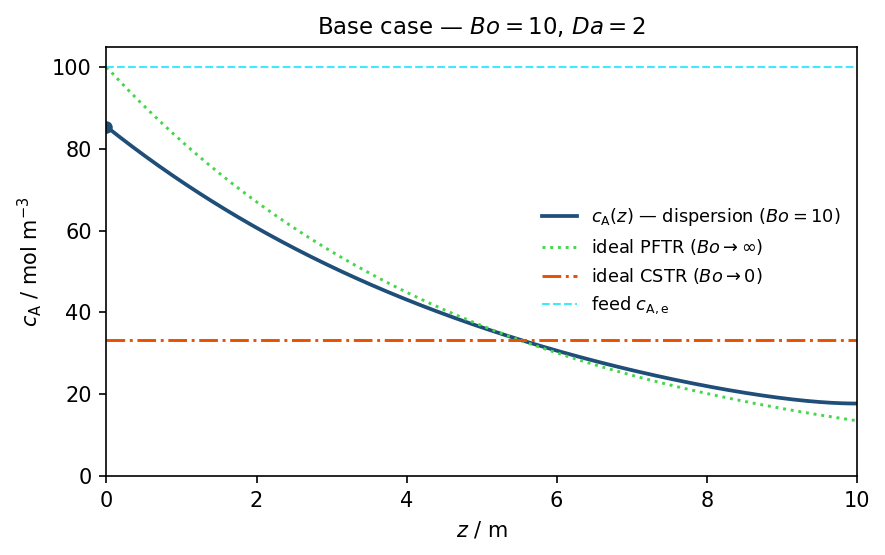

In [10]:
# ============================================================
# 3.2  PLOT — base-case profile with ideal-reactor references
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6, 3.8, 150
col_disp, col_pfr, col_cstr, col_feed = "#1f4e79", "#45d64c", "#e65100", "#3fe9ff"
lw_disp, n_eval = 1.8, 400

# --- data ---
z_eval  = np.linspace(0, L, n_eval)
cA_eval = sol.sol(z_eval)[0]
cA0     = sol.sol(0.0)[0]
cA_cstr = c_A_in * (1 - X_cstr(Da))          # constant level of an ideal CSTR (same tau)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)
ax.plot(z_eval, cA_eval, color=col_disp, lw=lw_disp,
        label=rf"$c_\mathrm{{A}}(z)$ — dispersion ($Bo={Bo:.0f}$)")
ax.plot(z_eval, cA_pfr_profile(z_eval, c_A_in, k, u), color=col_pfr, lw=1.4, ls=":",
        label=r"ideal PFTR ($Bo\to\infty$)")
ax.axhline(cA_cstr, color=col_cstr, lw=1.4, ls="-.",
           label=r"ideal CSTR ($Bo\to 0$)")
ax.axhline(c_A_in, color=col_feed, lw=1.0, ls="--",
           label=r"feed $c_\mathrm{A,e}$")
ax.plot(0, cA0, "o", color=col_disp, ms=5)

ax.set_xlabel(r"$z$ / m")
ax.set_ylabel(r"$c_\mathrm{A}$ / mol m$^{-3}$")
ax.set_xlim(0, L)
ax.set_ylim(0, c_A_in * 1.05)
ax.set_title(rf"Base case — $Bo = {Bo:.0f}$, $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="right")
fig.tight_layout()
plt.show()

In [12]:
# ============================================================
# 4.1  VALIDATION — BVP vs analytical solution over Bo
# ============================================================
def solve_dispersion(Bo, N=400):
    "Solve the dispersion-model BVP for a given Bodenstein number; return the solution object."
    "This is a wrapper around the BVP solver to allow varying Bo while keeping other parameters fixed."
    "This is the function which will be validated numerically against the analytical solution X_dispersion(Bo, Da), and therefor used in the later assignment exclusively"
    D   = u * L / Bo
    fun = partial(dispersion_rhs, k=k, D=D, u=u)
    bc  = partial(dispersion_bc,  D=D, u=u, c_in=c_A_in)
    z   = np.linspace(0, L, N)
    yg  = np.zeros((2, N))
    yg[0] =  c_A_in * np.exp(-k / u * z)                            # Guess for c_A(z) based on ideal PFR solution
    yg[1] = -k / u * c_A_in * np.exp(-k / u * z)                    # Derivation of first guess, since the BVP solver needs a guess for both c_A and its derivative
    return solve_bvp(fun, bc, z, yg, tol=1e-8, max_nodes=200000)

# --- Bo grid spanning CSTR-like to PFR-like behaviour ---
Bo_check = np.logspace(-2, 4, 13)        # 0.01 ... 10000

# --- numerical (BVP) vs analytical (Guettel Gl. 15.6) conversion ---
X_bvp = np.array([1 - solve_dispersion(Bo_i).sol(L)[0] / c_A_in for Bo_i in Bo_check])                          # Saves the outlet conversion X = 1 - c_A(L)/c_A,e for each Bo_i in the Bo_check array
X_ana = X_dispersion(Bo_check, Da)                                                                              # Calculates the analytical outlet conversion X = 1 - c_A(L)/c_A,e for each Bo_i in the Bo_check array using the analytical formula from Guettel Gl. 15.6

# --- report ---
print(f"{'Bo':>10} | {'X_BVP':>9} | {'X_analytical':>12} | {'abs. diff':>10}")
print("-" * 52)
for Bo_i, xb, xa in zip(Bo_check, X_bvp, X_ana):
    print(f"{Bo_i:>10.2f} | {xb:>9.5f} | {xa:>12.5f} | {abs(xb-xa):>10.1e}")
print("-" * 52)
print(f"max. absolute deviation   : {np.max(np.abs(X_bvp - X_ana)):.2e}")
print(f"ideal CSTR limit (Bo->0)  : X = {X_cstr(Da):.5f}")
print(f"ideal PFTR limit (Bo->inf): X = {X_pfr(Da):.5f}")

        Bo |     X_BVP | X_analytical |  abs. diff
----------------------------------------------------
      0.01 |   0.66740 |      0.66740 |    9.0e-11
      0.03 |   0.66898 |      0.66898 |    0.0e+00
      0.10 |   0.67381 |      0.67381 |    4.4e-16
      0.32 |   0.68762 |      0.68762 |    3.7e-15
      1.00 |   0.72061 |      0.72061 |    2.2e-14
      3.16 |   0.77396 |      0.77396 |    6.6e-14
     10.00 |   0.82267 |      0.82267 |    1.0e-13
     31.62 |   0.84901 |      0.84901 |    1.5e-13
    100.00 |   0.85941 |      0.85941 |    2.0e-13
    316.23 |   0.86297 |      0.86297 |    2.2e-13
   1000.00 |   0.86412 |      0.86412 |    2.3e-13
   3162.28 |   0.86449 |      0.86449 |    2.3e-13
  10000.00 |   0.86461 |      0.86461 |    1.8e-13
----------------------------------------------------
max. absolute deviation   : 8.96e-11
ideal CSTR limit (Bo->0)  : X = 0.66667
ideal PFTR limit (Bo->inf): X = 0.86466


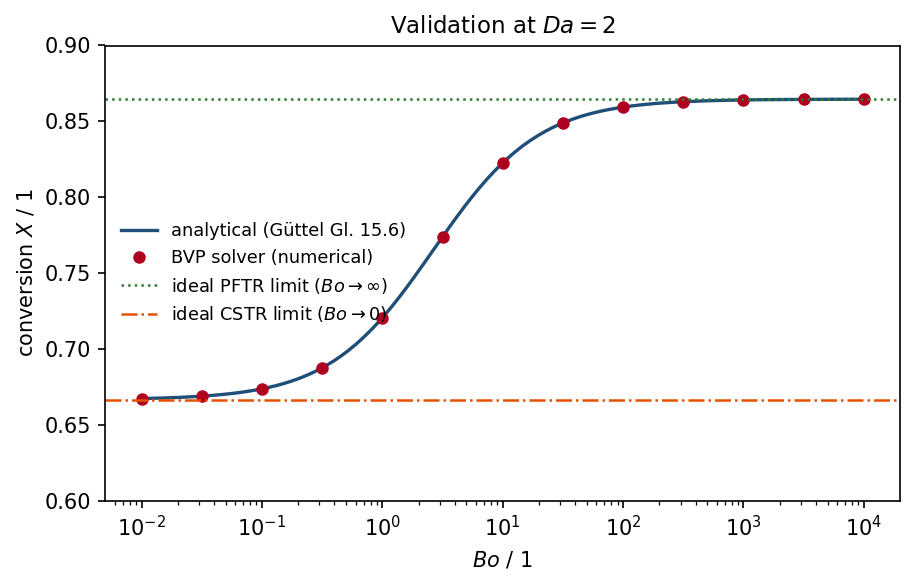

In [ ]:
# ============================================================
# 4.1  PLOT — validation of the BVP against analytical limits
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6.2, 4, 150
col_ana, col_bvp, col_pfr, col_cstr = "#1f4e79", "#b00020", "#2e7d32", "#e65100"
n_line = 200

# --- smooth analytical curve + BVP markers ---
Bo_line = np.logspace(-2, 4, n_line)                                            # Gives the evaluation points for the analytical solution X_dispersion(Bo, Da) to be plotted as a smooth curve
X_line  = X_dispersion(Bo_line, Da)                                             # Calculates the analytical outlet conversion X = 1 - c_A(L)/c_A,e for each Bo_i in the Bo_line array using the analytical formula from Guettel Gl. 15.6

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)
ax.plot(Bo_line, X_line, color=col_ana, lw=1.6, label="analytical (Güttel Gl. 15.6)")
ax.plot(Bo_check, X_bvp, "o", color=col_bvp, ms=5, label="BVP solver (numerical)")
ax.axhline(X_pfr(Da),  color=col_pfr,  lw=1.2, ls=":",  label=r"ideal PFTR limit ($Bo\to\infty$)")
ax.axhline(X_cstr(Da), color=col_cstr, lw=1.2, ls="-.", label=r"ideal CSTR limit ($Bo\to 0$)")

ax.set_xscale("log")
ax.set_xlabel(r"$Bo$ / 1")
ax.set_ylabel(r"conversion $X$ / 1")
ax.set_ylim(0.6, 0.9)
ax.set_title(rf"Validation at $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="center left")
fig.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4.2  Bo-SWEEP — concentration profiles (Guettel Abb. 15.2 style)
# ============================================================
# Fixed Da, varying Bo: the profile transitions from CSTR-like (low Bo,
# strong backmixing) to PFR-like (high Bo, weak backmixing).

Bo_sweep = np.array([0.5, 1, 3, 10, 30, 100])

# solve the BVP for each Bo and store the dimensionless profile f_A = c_A / c_A,e
n_prof   = 400
zeta     = np.linspace(0, 1, n_prof)                # dimensionless axial coordinate z/L
profiles = []                                       # storage list
print(f"{'Bo':>6} | {'f(0)':>6} | {'f(L)':>6} | {'X':>6}")
print("-" * 33)
for Bo_i in Bo_sweep:
    sol_i = solve_dispersion(Bo_i, N=400)
    f_i   = sol_i.sol(zeta * L)[0] / c_A_in        # f_A(zeta) = c_A(z) / c_A,e
    profiles.append(f_i)
    print(f"{Bo_i:>6.1f} | {f_i[0]:>6.3f} | {f_i[-1]:>6.3f} | {1 - f_i[-1]:>6.3f}")

    Bo |   f(0) |   f(L) |      X
---------------------------------
   0.5 |  0.442 |  0.302 |  0.698
   1.0 |  0.519 |  0.279 |  0.721
   3.0 |  0.687 |  0.229 |  0.771
  10.0 |  0.854 |  0.177 |  0.823
  30.0 |  0.941 |  0.152 |  0.848
 100.0 |  0.981 |  0.141 |  0.859


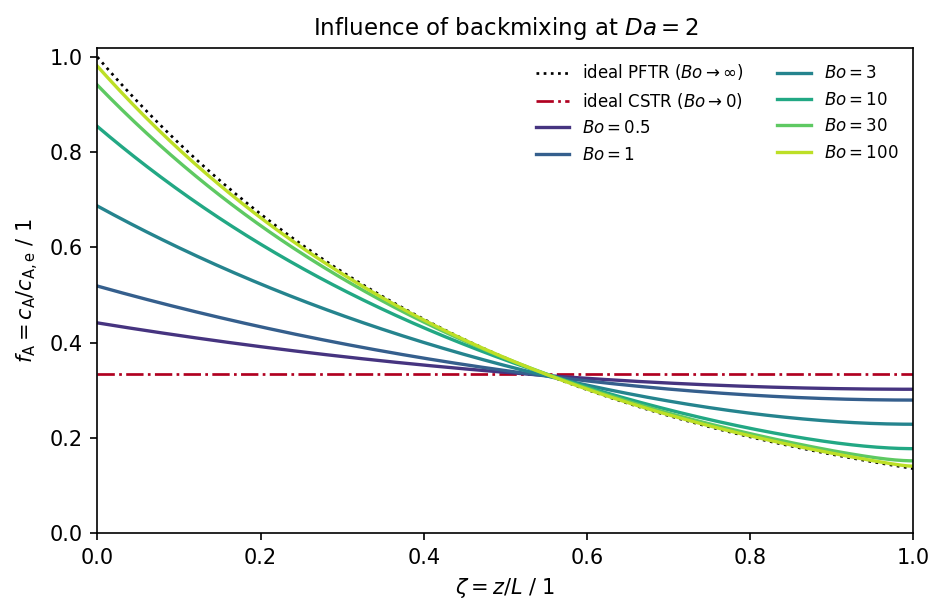

In [9]:
# ============================================================
# 4.2  PLOT — Bo-sweep concentration profiles
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi = 6.4, 4.2, 150
cmap     = plt.cm.viridis
col_pfr  = "#000000"
col_cstr = "#b00020"
lw_prof  = 1.6
n_cases  = len(Bo_sweep)

# colour-grade the BVP profiles by their position in the sweep (low -> high Bo)
colors = cmap(np.linspace(0.15, 0.9, n_cases))

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=fig_dpi)

# analytical bounding cases (theoretical limits)
ax.plot(zeta, np.exp(-Da * zeta), color=col_pfr, lw=1.3, ls=":",
        label=r"ideal PFTR ($Bo\to\infty$)")
ax.axhline(1 / (1 + Da), color=col_cstr, lw=1.3, ls="-.",
           label=r"ideal CSTR ($Bo\to 0$)")

# BVP profiles for increasing Bo
for f_i, Bo_i, c in zip(profiles, Bo_sweep, colors):
    ax.plot(zeta, f_i, color=c, lw=lw_prof, label=rf"$Bo = {Bo_i:g}$")

ax.set_xlabel(r"$\zeta = z/L$ / 1")
ax.set_ylabel(r"$f_\mathrm{A} = c_\mathrm{A}/c_\mathrm{A,e}$ / 1")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title(rf"Influence of backmixing at $Da = {Da:.0f}$", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper right", ncol=2)
fig.tight_layout()
plt.show()

# Kaskadenmodell anwendbar, da wir keinerlei Wärmeentwicklung betrachten, und daher K rein für Bo passend gewählt werden kann.

In [13]:
# ============================================================
# 4.3  CSTR CASCADE MODEL — comparison with dispersion model
# ============================================================
# Cascade of K equal-sized ideal CSTRs, isothermal, 1st-order reaction.
# Closed-form conversion (Guettel Gl. 15.14, p. 213), derived from the
# single-CSTR balance (Gl. 12.1a) applied recursively over K vessels.

def X_cascade(K, Da):
    "Conversion of a cascade of K equal ideal CSTRs (Guettel Gl. 15.14, p. 213)."
    return 1 - 1 / (1 + Da / K)**K

# --- selected Bo values: two from the Task-2 sweep (30, 100) + four new ---
Bo_cascade = np.array([30, 50, 75, 100, 200, 500])
K_cascade  = Bo_cascade / 2          # Guettel Gl. 15.13, p. 213: K = Bo/2

# --- validity classification of Gl. 15.13 (Guettel, p. 213) ---
def K_validity(K):
    "Validity range of K = Bo/2 (Guettel, p. 213): exact for K>=50, approx. for 10<=K<50."
    if K >= 50:
        return "exact (K >= 50)"
    elif K >= 10:
        return "approx. (10 <= K < 50)"
    else:
        return "not valid (K < 10)"

# --- comparison: cascade vs. dispersion model at matching Bo ---
X_casc = X_cascade(K_cascade, Da)
X_disp = np.array([1 - solve_dispersion(Bo_i).sol(L)[0] / c_A_in for Bo_i in Bo_cascade])

print(f"{'Bo':>6} | {'K=Bo/2':>7} | {'validity':>22} | {'X_cascade':>10} | {'X_dispersion':>12} | {'abs. diff':>10}")
print("-" * 82)
for Bo_i, K_i, Xc, Xd in zip(Bo_cascade, K_cascade, X_casc, X_disp):
    print(f"{Bo_i:>6.0f} | {K_i:>7.1f} | {K_validity(K_i):>22} | {Xc:>10.5f} | {Xd:>12.5f} | {abs(Xc-Xd):>10.2e}")

    Bo |  K=Bo/2 |               validity |  X_cascade | X_dispersion |  abs. diff
----------------------------------------------------------------------------------
    30 |    15.0 | approx. (10 <= K < 50) |    0.84702 |      0.84824 |   1.22e-03
    50 |    25.0 | approx. (10 <= K < 50) |    0.85398 |      0.85444 |   4.63e-04
    75 |    37.5 | approx. (10 <= K < 50) |    0.85751 |      0.85772 |   2.12e-04
   100 |    50.0 |        exact (K >= 50) |    0.85929 |      0.85941 |   1.21e-04
   200 |   100.0 |        exact (K >= 50) |    0.86197 |      0.86200 |   3.09e-05
   500 |   250.0 |        exact (K >= 50) |    0.86358 |      0.86359 |   5.01e-06


In [ ]:
# ============================================================
# 4.3  CSTR CASCADE — stepwise concentration profiles
# ============================================================
# Note: K = Bo/2 (Guettel Gl. 15.13) is generally non-integer (e.g. Bo=75 -> K=37.5).
# For an actual staircase profile we need a whole number of physical vessels,
# so K is rounded to the nearest integer here. This rounding only affects the
# visualization, NOT the U(Da,K) values reported in the table above (Gl. 15.14
# is evaluated there with the exact, continuous K).

K_int_cascade = np.round(K_cascade).astype(int)   # rounded vessel count per Bo case

def cascade_profile(K, Da):
    "Stepwise f_A = c_A/c_A,e at vessel boundaries (0=inlet, K=outlet) for K equal CSTRs."
    k_idx = np.arange(0, K + 1)
    f_A   = 1.0 / (1 + Da / K)**k_idx               # Guettel Gl. 15.14 building block, per vessel
    zeta  = k_idx / K                               # dimensionless position (equal vessel volumes)
    return zeta, f_A

print(f"{'Bo':>6} | {'K (exact)':>10} | {'K (rounded)':>12}")
print("-" * 34)
for Bo_i, Ke, Ki in zip(Bo_cascade, K_cascade, K_int_cascade):
    print(f"{Bo_i:>6.0f} | {Ke:>10.1f} | {Ki:>12d}")

    Bo |  K (exact) |  K (rounded)
----------------------------------
    30 |       15.0 |           15
    50 |       25.0 |           25
    75 |       37.5 |           38
   100 |       50.0 |           50
   200 |      100.0 |          100
   500 |      250.0 |          250


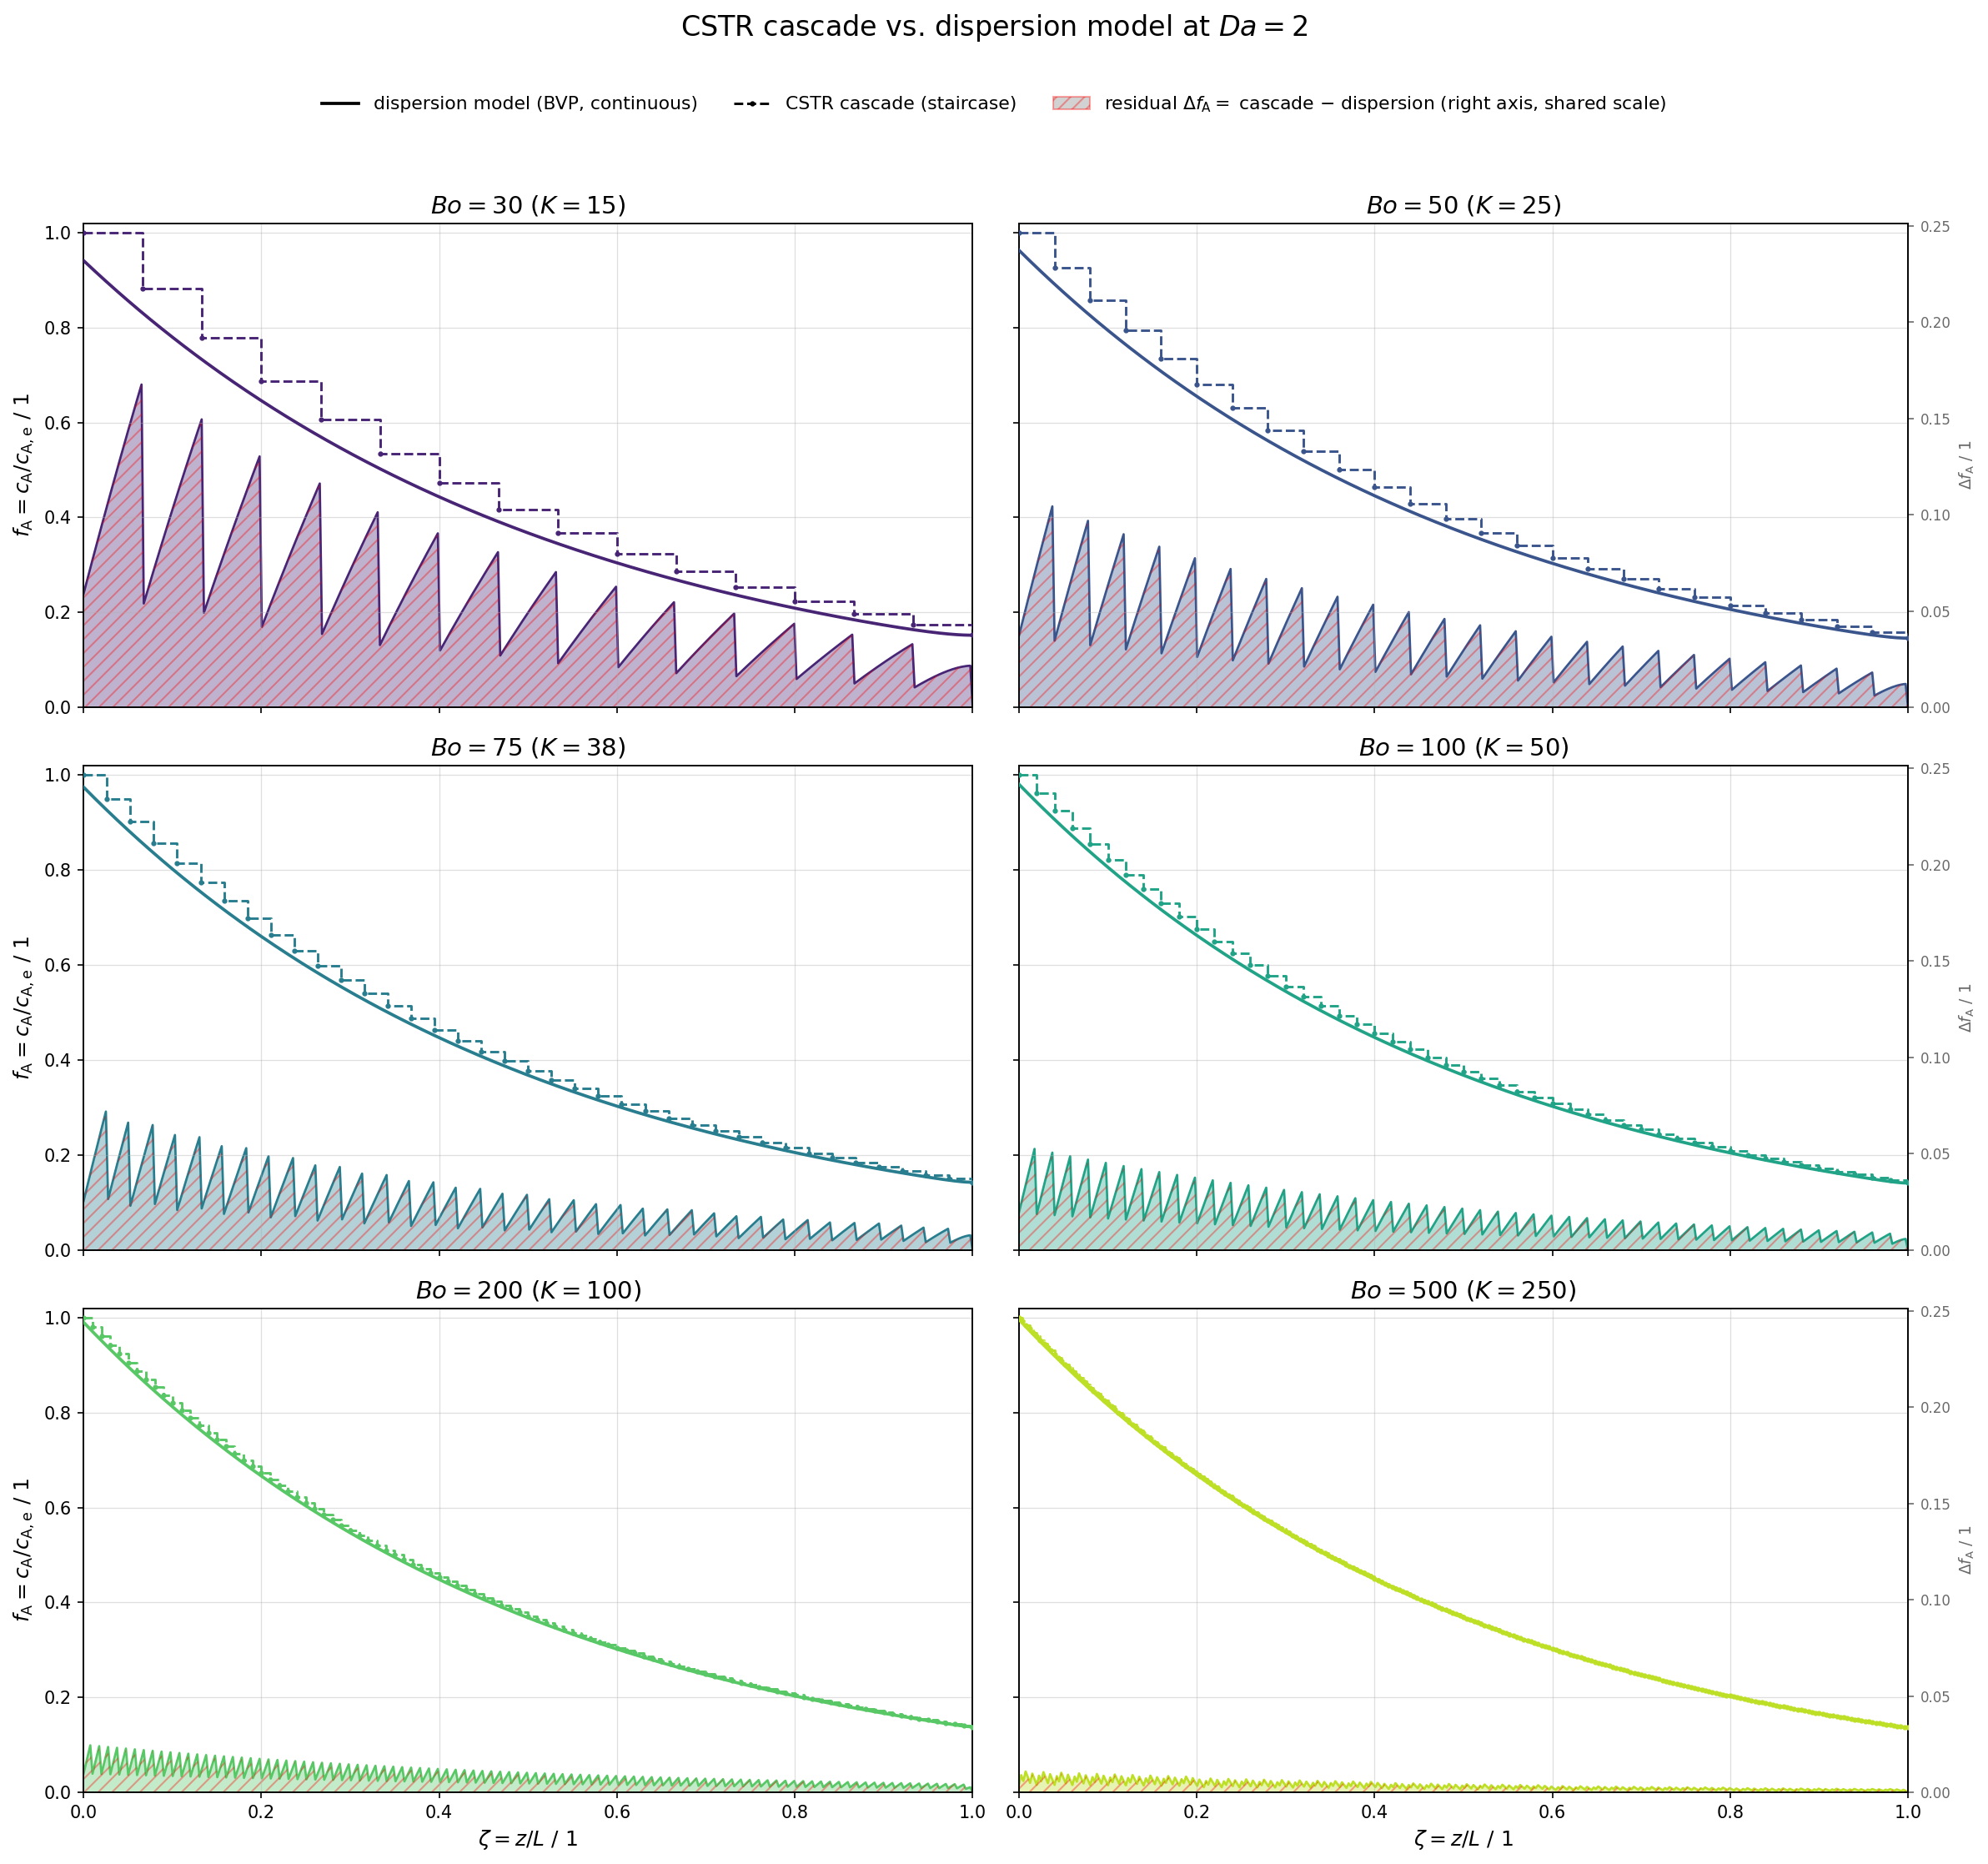

In [26]:
# ============================================================
# 4.3  PLOT — CSTR cascade (staircase) vs. dispersion model
#             + hatched residual area (shared scale across all Bo cases)
#             all axis labels/ticks only on outer subplots
#             (x: bottom row, y1: left col, y2: right col)
# ============================================================
# --- plot variables (top of cell) ---
fig_w, fig_h, fig_dpi     = 16, 15, 150
n_rows, n_cols            = 3, 2
cmap                      = plt.cm.viridis
n_cases                   = len(Bo_cascade)
colors                    = cmap(np.linspace(0.1, 0.9, n_cases))
lw_disp, lw_casc, ms_casc, lw_diff = 1.8, 1.4, 2, 1.3
n_eval                    = 400
zeta_eval                 = np.linspace(0, 1, n_eval)
grid_lw, grid_alpha       = 0.6, 0.4
fill_alpha                = 0.35
hatch_pattern, hatch_color = "///", "red"

def step_eval_post(zeta_query, zeta_nodes, f_nodes):
    "Evaluate the same 'post'-style step function used by ax.step(where='post') at arbitrary zeta."
    idx = np.searchsorted(zeta_nodes, zeta_query, side="right") - 1
    idx = np.clip(idx, 0, len(f_nodes) - 1)
    return f_nodes[idx]

# --- pre-compute residuals for ALL cases first, to fix one shared secondary-axis scale ---
diff_lines = {}
for Bo_i, K_i in zip(Bo_cascade, K_int_cascade):
    sol_i       = solve_dispersion(Bo_i)
    f_disp      = sol_i.sol(zeta_eval * L)[0] / c_A_in
    zeta_c, f_c = cascade_profile(K_i, Da)
    f_step      = step_eval_post(zeta_eval, zeta_c, f_c)
    diff_lines[Bo_i] = f_step - f_disp

all_diffs  = np.concatenate(list(diff_lines.values()))
diff_ylim  = (min(0, all_diffs.min()) * 1.05, all_diffs.max() * 1.5)   # SAME for all 6 panels

fig, axes  = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), dpi=fig_dpi,
                           sharex=True, sharey=True)
axes_flat  = axes.flatten()

for idx, (ax, Bo_i, K_i, c) in enumerate(zip(axes_flat, Bo_cascade, K_int_cascade, colors)):
    is_right_col = (idx % n_cols == n_cols - 1)     # True only for column 2 (rightmost)

    # dispersion model: smooth profile, solid line
    sol_i  = solve_dispersion(Bo_i)
    f_disp = sol_i.sol(zeta_eval * L)[0] / c_A_in
    ax.plot(zeta_eval, f_disp, color=c, lw=lw_disp, ls="-", zorder=4)

    # CSTR cascade: staircase profile, dashed + markers
    zeta_c, f_c = cascade_profile(K_i, Da)
    ax.step(zeta_c, f_c, where="post", color=c, lw=lw_casc, ls="--", zorder=3)
    ax.plot(zeta_c, f_c, "o", color=c, ms=ms_casc, zorder=5)

    # residual: cascade staircase minus dispersion, filled + red-hatched, shared scale
    diff_line = diff_lines[Bo_i]
    ax2 = ax.twinx()
    ax2.plot(zeta_eval, diff_line, color=c, lw=lw_diff, zorder=1)
    ax2.fill_between(zeta_eval, 0, diff_line, facecolor=c, alpha=fill_alpha,
                      hatch=hatch_pattern, edgecolor=hatch_color, linewidth=0.0, zorder=1)
    ax2.axhline(0, color="gray", lw=0.6, alpha=0.6, zorder=0)
    ax2.set_ylim(diff_ylim)                           # identical range on every subplot

    if is_right_col:                                   # axis title + tick numbers: outer (right) column only
        ax2.set_ylabel(r"$\Delta f_\mathrm{A}$ / 1", fontsize=9, color="dimgray")
        ax2.tick_params(axis="y", labelsize=8, colors="dimgray")
    else:                                               # inner plots: no numbers, no tick marks
        ax2.tick_params(axis="y", labelright=False, length=0)

    ax.set_zorder(2); ax2.set_zorder(1); ax.patch.set_visible(False)
    ax.set_title(rf"$Bo = {Bo_i:g}$ ($K = {K_i:d}$)", fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(True, lw=grid_lw, alpha=grid_alpha, zorder=0)

for a in axes[-1, :]:
    a.set_xlabel(r"$\zeta = z/L$ / 1", fontsize=12)      # only bottom row
for a in axes[:, 0]:
    a.set_ylabel(r"$f_\mathrm{A} = c_\mathrm{A}/c_\mathrm{A,e}$ / 1", fontsize=12)   # only left column

# --- single shared legend, outside the subplot grid ---
style_handles = [
    Line2D([0], [0], color="black", lw=lw_disp, ls="-",
           label="dispersion model (BVP, continuous)"),
    Line2D([0], [0], color="black", lw=lw_casc, ls="--", marker="o", ms=ms_casc,
           label="CSTR cascade (staircase)"),
    Patch(facecolor="gray", alpha=fill_alpha, hatch=hatch_pattern, edgecolor=hatch_color,
          label=r"residual $\Delta f_\mathrm{A} =$ cascade $-$ dispersion (right axis, shared scale)"),
]
fig.suptitle(rf"CSTR cascade vs. dispersion model at $Da = {Da:.0f}$", fontsize=16, y=0.99)
fig.legend(handles=style_handles, loc="upper center", bbox_to_anchor=(0.5, 0.955),
           ncol=3, fontsize=10.5, frameon=False)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# **4. Results and Discussion**

## 6. AI Use and Reflection

### 6.1 Tools Used

| Tool | Model / Version | Date(s) of Use |
|------|-----------------|----------------|
| Claude | Sonnet 4.6 | [Month Year] |
| [Additional tool, if any] | [Version] | [Date] |

---

### 6.2 Areas of Use

| Subtask | AI Used? | Notes |
|---------|----------|-------|
| Literature / data research | [ ] Yes / [x] No | |
| Code generation | [x] Yes | BVP / IVP implementation |
| Code debugging | [x] Yes | [brief description] |
| Verification strategy | [ ] Yes / [ ] No | |
| Concept clarification (self-study) | [ ] Yes / [ ] No | |
| Interpretation of numerical results | [ ] Yes / [ ] No | |
| Language editing / proof-reading | [ ] Yes / [ ] No | |

---

### 6.3 Prompting Strategy

**Code generation (BVP implementation):**
[Describe briefly: What context did you provide? How did you structure the prompt? Example: "Provided the governing equations, boundary conditions, and solver requirements; asked for implementation using `solve_bvp` with Danckwerts BCs; iterated based on solver success flags."]

**Debugging:**
[Describe: What error occurred? How did you describe it to the AI? Example: "Provided full traceback; AI identified an incorrect stacking order in the BVP return vector."]

**[Other use case, if applicable]:**
[Description]

---

### 6.4 Critical Examination

The following issues were identified and corrected in AI-generated outputs:

| Issue | Detected via | Correction applied |
|-------|-------------|-------------------|
| [e.g. Wrong sign in Danckwerts BC at z=0] | [e.g. Comparison with Danckwerts (1953) [2]] | [e.g. Corrected sign of the diffusive flux term] |
| [Issue 2] | [Method] | [Correction] |

AI outputs were verified against the assignment background equations, the referenced literature [1, 2], and the analytical limiting cases (Bo → ∞ for ideal PFR, Bo → 0 for ideal CSTR). [Add further verification steps as performed.]

---

### 6.5 Statement of Own Contribution

The scientific reasoning, engineering interpretation, and discussion of results in this report are independent work of the authors. AI was used exclusively for code implementation and debugging; the underlying modelling logic, choice of parameter variations, and result discussion were developed independently by the authors.

---

## 📋 Progress Tracker — Assignment 4

> **Last updated:** 30.06.2026 &emsp; **Status:** 🔴 Not started &emsp; 🟡 In progress &emsp; 🟢 Done

### Core Tasks (from Assignment)

| # | Task | Status | Comments / Notes |
|---|------|--------|-----------------|
| T-1 | **BVP implementation** — Dispersion model with Danckwerts BCs using `solve_bvp` | 🟢 | |
| T-2 | **Validation** — BVP result compared against IVP (PFR limiting case, Bo → ∞) | 🟢 | |
| T-3 | **Bo-number variation** — systematic variation of dispersion, discuss boundary cases (CSTR/PFR limits) | 🟡 | |
| T-4 | **CSTR cascade implementation** — compare to dispersion model at three distinct Bo values | 🔴 | |

### Grading Criteria Checklist

| # | Criterion (Grading Scheme) | Weight | Status | Notes |
|---|---------------------------|--------|--------|-------|
| I-1 | Text quality (language, style, grammar) | 10% × 0.25 | 🔴 | |
| I-2 | Figures (labels, legends, readability, referenced in text) | 10% × 0.25 | 🔴 | |
| I-3 | Equations (formatted, variables defined, consistent units) | 10% × 0.25 | 🔴 | |
| I-4 | Report structure (logical flow, balanced sections, headings) | 10% × 0.25 | 🔴 | |
| II-1 | Theoretical background (relevant, accurate, linked to assignment) | 20% × 0.5 | 🔴 | |
| II-2 | Motivation & relevance (why this matters in reaction engineering) | 20% × 0.5 | 🔴 | |
| III-1 | FAIR / readable code (comments, variable names, units, structure) | 25% × 0.25 | 🔴 | |
| III-2 | Code matches report text (methods described = methods implemented) | 25% × 0.25 | 🔴 | |
| III-3 | Documentation of methods (reproducible: versions, data, parameters) | 25% × 0.25 | 🔴 | |
| III-4 | Validation strategy (limiting cases, convergence, sanity checks) | 25% × 0.25 | 🔴 | |
| IV-1 | Plausibility of results (orders of magnitude, limiting cases) | 35% × 0.2 | 🔴 | |
| IV-2 | Connection to theory (results discussed against background) | 35% × 0.2 | 🔴 | |
| IV-3 | Significance of parameter study (informative variation, conclusions) | 35% × 0.2 | 🔴 | |
| IV-4 | Independent interpretation (own reasoning visible, not generic) | 35% × 0.2 | 🔴 | |
| IV-5 | Link to industrial application (concrete, realistic scenario) | 35% × 0.2 | 🔴 | |
| V-1 | AI transparency (tools, purposes, example prompts documented) | 10% × 0.5 | 🔴 | |
| V-2 | Critical AI evaluation (output verified, errors identified) | 10% × 0.5 | 🔴 | |

### Open Questions / Blockers

- [ ] Reaction order confirmed as 1st order for base case — higher orders need common reference for comparison
- [ ] Dispersion coefficient range to use (assignment hint: at least in range of diffusion coefficient)
- [ ] [Add further open questions here]

### Submission Deadline

`12.07.2026`

---